In [236]:
import matplotlib.pyplot as plt
import contextily as cx
import matplotlib.ticker as mtick

import osmnx as ox
import geopandas as gpd
import networkx as nx

from shapely.geometry import MultiPoint, Point, box

In [237]:
def get_clean_pitches(square_bbox, local_epsg):
    """Fetches and cleans soccer pitches for a given city."""
    tags = {
        'leisure': ['pitch'],
        'sport': ['soccer']
    }
    gdf = ox.features_from_bbox(square_bbox, tags=tags)
    
    gdf = gdf[gdf['sport'].str.contains('soccer', na=False)].copy()
    gdf = gdf[gdf['leisure'].notnull()]
    
    gdf['geometry'] = gdf.geometry.representative_point()
    
    # Project to metric CRS
    gdf = gdf.to_crs(epsg=local_epsg)
    
    return gdf[['name', 'geometry']]

In [238]:
def create_catchment_mask(pitches_gdf, G, walk_radius=1125):
    """Calculates 15-min walk networks and melts them into a single polygon mask."""
    catchment_polygons = []
    
    for _, row in pitches_gdf.iterrows():
        # 1. Snap to network
        center_node = ox.distance.nearest_nodes(G, row.geometry.x, row.geometry.y)
        
        # 2. Extract walkable subgraph (Dijkstra)
        subgraph = nx.ego_graph(G, center_node, radius=walk_radius, distance='length')
        
        # 3. Create Convex Hull
        if len(subgraph.nodes) > 2: # Certify it's a polygon
            node_points = MultiPoint([Point(G.nodes[n]['x'], G.nodes[n]['y']) for n in subgraph.nodes])
            catchment_polygons.append(node_points.convex_hull)
            
    # Melt all individual pitch hulls into one unified coverage mask
    melted_shape = gpd.GeoSeries(catchment_polygons).union_all()
    
    # Wrap in a blank GeoDataFrame
    mask_gdf = gpd.GeoDataFrame(geometry=[melted_shape], crs=pitches_gdf.crs)
    
    return mask_gdf

In [239]:
def calculate_spatial_equity(neighborhoods_gdf, mask_gdf):
    """Overlays the mask onto provided neighborhoods and calculates coverage percentage."""
    neighborhoods_gdf['total_area'] = neighborhoods_gdf.geometry.area
    
    # Overlay the spatial mask (Intersection)
    covered_areas = gpd.overlay(neighborhoods_gdf, mask_gdf, how='intersection')
    covered_areas['covered_area'] = covered_areas.geometry.area
    
    # Merge and calculate percentage
    final_gdf = neighborhoods_gdf.merge(
        covered_areas[['name', 'covered_area']], 
        on='name', 
        how='left'
    )
    final_gdf['covered_area'] = final_gdf['covered_area'].fillna(0)
    final_gdf['coverage_pct'] = (final_gdf['covered_area'] / final_gdf['total_area']) * 100
    
    return final_gdf

In [240]:
place_name = "New York City, New York, USA"
center_point = (40.679453, -73.928032)
dist_meters = 5000
epsg_code = 2263

perfect_bbox = ox.utils_geo.bbox_from_point(center_point, dist=dist_meters)


# 1. Get Pitches
pitches = get_clean_pitches(perfect_bbox, epsg_code)

# 2. Get Walkable Network
test_graph = ox.graph_from_bbox(bbox=perfect_bbox, network_type="walk")

# Project graph to the same metric CRS
city_graph = ox.project_graph(test_graph, to_crs=epsg_code)

# 3. Build Mask
coverage_mask = create_catchment_mask(pitches, city_graph)


# Fetch and project the massive city-wide boundaries
nta_url = "https://services5.arcgis.com/GfwWNkhOj9bNBqoJ/arcgis/rest/services/NYC_Neighborhood_Tabulation_Areas_2020/FeatureServer/0/query?where=1=1&outFields=*&outSR=4326&f=pgeojson"

raw_neighborhoods = gpd.read_file(nta_url)
raw_neighborhoods = raw_neighborhoods.rename(columns={'NTAName': 'name'})

clipping_polygon = box(*perfect_bbox)
study_area_neighborhoods = raw_neighborhoods.clip(clipping_polygon)
study_area_neighborhoods = study_area_neighborhoods.to_crs(epsg=epsg_code)

# Running the calculation
equity_results = calculate_spatial_equity(study_area_neighborhoods, coverage_mask)

In [241]:
display(equity_results.head())

# display(raw_neighborhoods)

# display(raw_neighborhoods.geometry.geom_type.value_counts())
# display(raw_neighborhoods[raw_neighborhoods['geometry'].geom_type == 'Polygon'].geometry.geom_type.value_counts())

# print(raw_neighborhoods.NTAName.nunique())

,OBJECTID,BoroCode,BoroName,CountyFIPS,NTA2020,name,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape__Area,Shape__Length,geometry,total_area,covered_area,coverage_pct
0,40,3,Brooklyn,047,BK1202,Borough Park,BoroPk,0,BK12,BK12 Borough Park-Kensington (CD 12 Approximat...,4.048129e+07,28481.079045,"POLYGON ((987932.014 173751.148, 988163.593 17...",6.324292e+06,0.000000e+00,0.000000
1,48,3,Brooklyn,047,BK1402,Flatbush (West)-Ditmas Park-Parkville,Fltbsh_W,0,BK14,BK14 Flatbush-Midwood (CD 14 Approximation),2.290466e+07,31252.164281,"POLYGON ((992495.39 171140.902, 992753.69 1711...",1.233324e+07,5.494123e+06,44.547276
2,41,3,Brooklyn,047,BK1203,Kensington,Knsngtn,0,BK12,BK12 Borough Park-Kensington (CD 12 Approximat...,1.747123e+07,20316.734680,"POLYGON ((990664.145 170873.848, 990349.7 1708...",1.622951e+07,3.309836e+06,20.393936
3,60,3,Brooklyn,047,BK1801,Flatlands,Fltlnds,0,BK18,BK18 Canarsie-Flatlands (CD 18 Approximation),5.433718e+07,40597.277802,"POLYGON ((1001661.34 170506.105, 1001930.838 1...",5.616657e+06,0.000000e+00,0.000000
4,56,3,Brooklyn,047,BK1702,East Flatbush-Farragut,EFb_Frrgt,0,BK17,BK17 East Flatbush (CD 17 Approximation),2.412190e+07,23276.208823,"POLYGON ((1001654.112 173896.937, 1001913.734 ...",2.190801e+07,0.000000e+00,0.000000


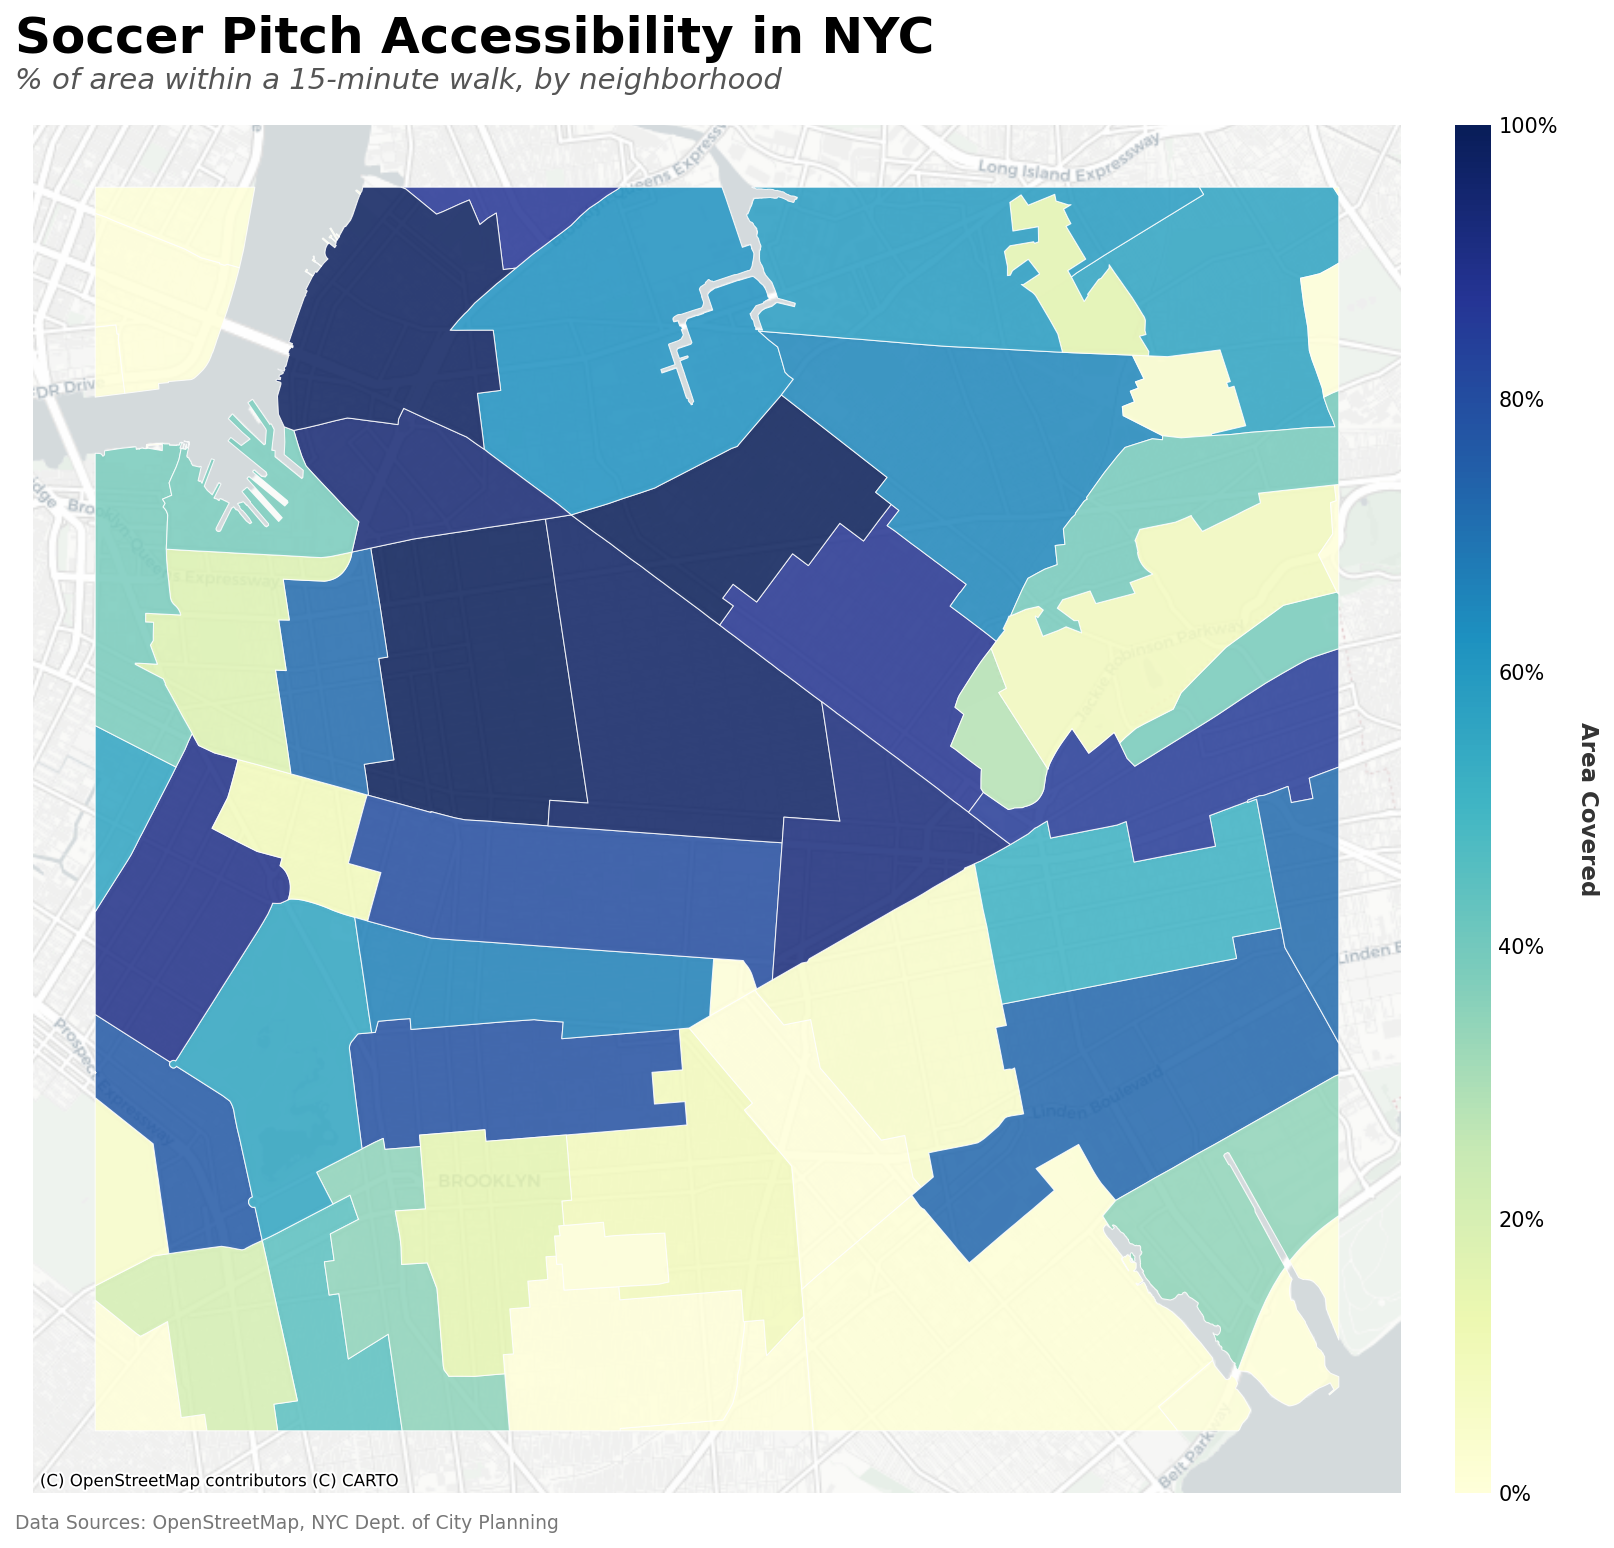

In [242]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
equity_results.to_crs(epsg=3857, inplace=True)


equity_results.plot(
    column='coverage_pct', 
    cmap='YlGnBu',
    edgecolor='white',
    linewidth=0.5,
    vmin=0,
    vmax=100,
    alpha=0.85,
    ax=ax
)

# Add basemap
cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron)


plt.figtext(0.05, 0.92, "Soccer Pitch Accessibility in NYC", fontsize=24, fontweight='bold', fontfamily='sans-serif')
plt.figtext(0.05, 0.90, "% of area within a 15-minute walk, by neighborhood", fontsize=14, color='#555555', fontfamily='sans-serif', fontstyle='italic')


# Coordinates: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.85, 0.12, 0.02, 0.76])
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=0, vmax=100))
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')

cbar.set_label("Area Covered", fontsize=11, fontweight='bold', color='#333333', rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
cbar.outline.set_visible(False)  
cbar.ax.tick_params(size=0, labelsize=10, color='#333333')

plt.figtext(0.05, 0.1, "Data Sources: OpenStreetMap, NYC Dept. of City Planning", fontsize=9, color='#777777')

ax.set_axis_off()
plt.subplots_adjust(left=0.06, right=0.82, top=0.9, bottom=0.1)

plt.show()

In [243]:
place_name = "Paris, France"
center_point = (48.8566, 2.3522)
dist_meters = 5000
epsg_code = 2154  # Official French metric CRS

perfect_bbox = ox.utils_geo.bbox_from_point(center_point, dist=dist_meters)

# 1. Get Pitches
pitches = get_clean_pitches(perfect_bbox, epsg_code)

# 2. Get Walkable Network
test_graph = ox.graph_from_bbox(bbox=perfect_bbox, network_type="walk")
city_graph = ox.project_graph(test_graph, to_crs=epsg_code)

# 3. Build Mask
coverage_mask = create_catchment_mask(pitches, city_graph)

# 4. Get Paris Quartiers (Level 10 in France)
raw_neighborhoods = ox.features_from_place(place_name, tags={'admin_level': '10'})

# Safety filter: ensuring to only keep the actual polygon boundaries, not stray points
raw_neighborhoods = raw_neighborhoods[raw_neighborhoods.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])]

# 5. Clip and Project
clipping_polygon = box(*perfect_bbox)
study_area_neighborhoods = raw_neighborhoods.clip(clipping_polygon)
study_area_neighborhoods = study_area_neighborhoods.to_crs(epsg=epsg_code)

# 6. Running the calculation
equity_results = calculate_spatial_equity(study_area_neighborhoods, coverage_mask)

In [244]:
display(equity_results)

,geometry,admin_level,boundary,name,place,cycleway:both,highway,lit,maxspeed,oneway,...,name:el,dog,alt_name,addr:postcode,official_name,alt_name:zh,colour,total_area,covered_area,coverage_pct
0,"POLYGON ((649895.962 6857474.963, 649897.792 6...",10,administrative,Quartier Vieux Montrouge,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,#89d1ef,3.322136e+05,3.322136e+05,100.000000
1,"POLYGON ((649333.939 6857907.849, 649344.595 6...",10,administrative,Quartier Portes de Montrouge,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,#78b1be,2.729226e+05,2.729226e+05,100.000000
2,"POLYGON ((647488.851 6859154.6, 647500.033 685...",10,administrative,Quartier Centre-Ville / Corentin Celton / Les ...,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.729037e+04,6.421041e+04,83.076865
3,"POLYGON ((648706.013 6858573.007, 648784.676 6...",10,administrative,Quartier de Plaisance,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.774753e+06,1.694747e+06,95.492022
4,"POLYGON ((647442.63 6859602.298, 647435.373 68...",10,administrative,Quartier Saint-Lambert,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.750548e+06,2.598930e+06,94.487711
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,"POLYGON ((652262.092 6864356.534, 652265.582 6...",10,administrative,Quartier Saint-Vincent-de-Paul,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.275872e+05,9.201913e+05,99.202678
90,"POLYGON ((653416.728 6865124.705, 653524.478 6...",10,administrative,Quartier de la Villette,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.285596e+06,1.285596e+06,100.000000
91,"POLYGON ((652294.257 6865060.15, 652294.011 68...",10,administrative,Quartier de la Goutte-d'Or,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.088548e+06,1.087697e+06,99.921801
92,"POLYGON ((653826.959 6867021.32, 653827.016 68...",10,administrative,Quartier de la Chapelle,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.330781e+06,1.327695e+06,99.768059


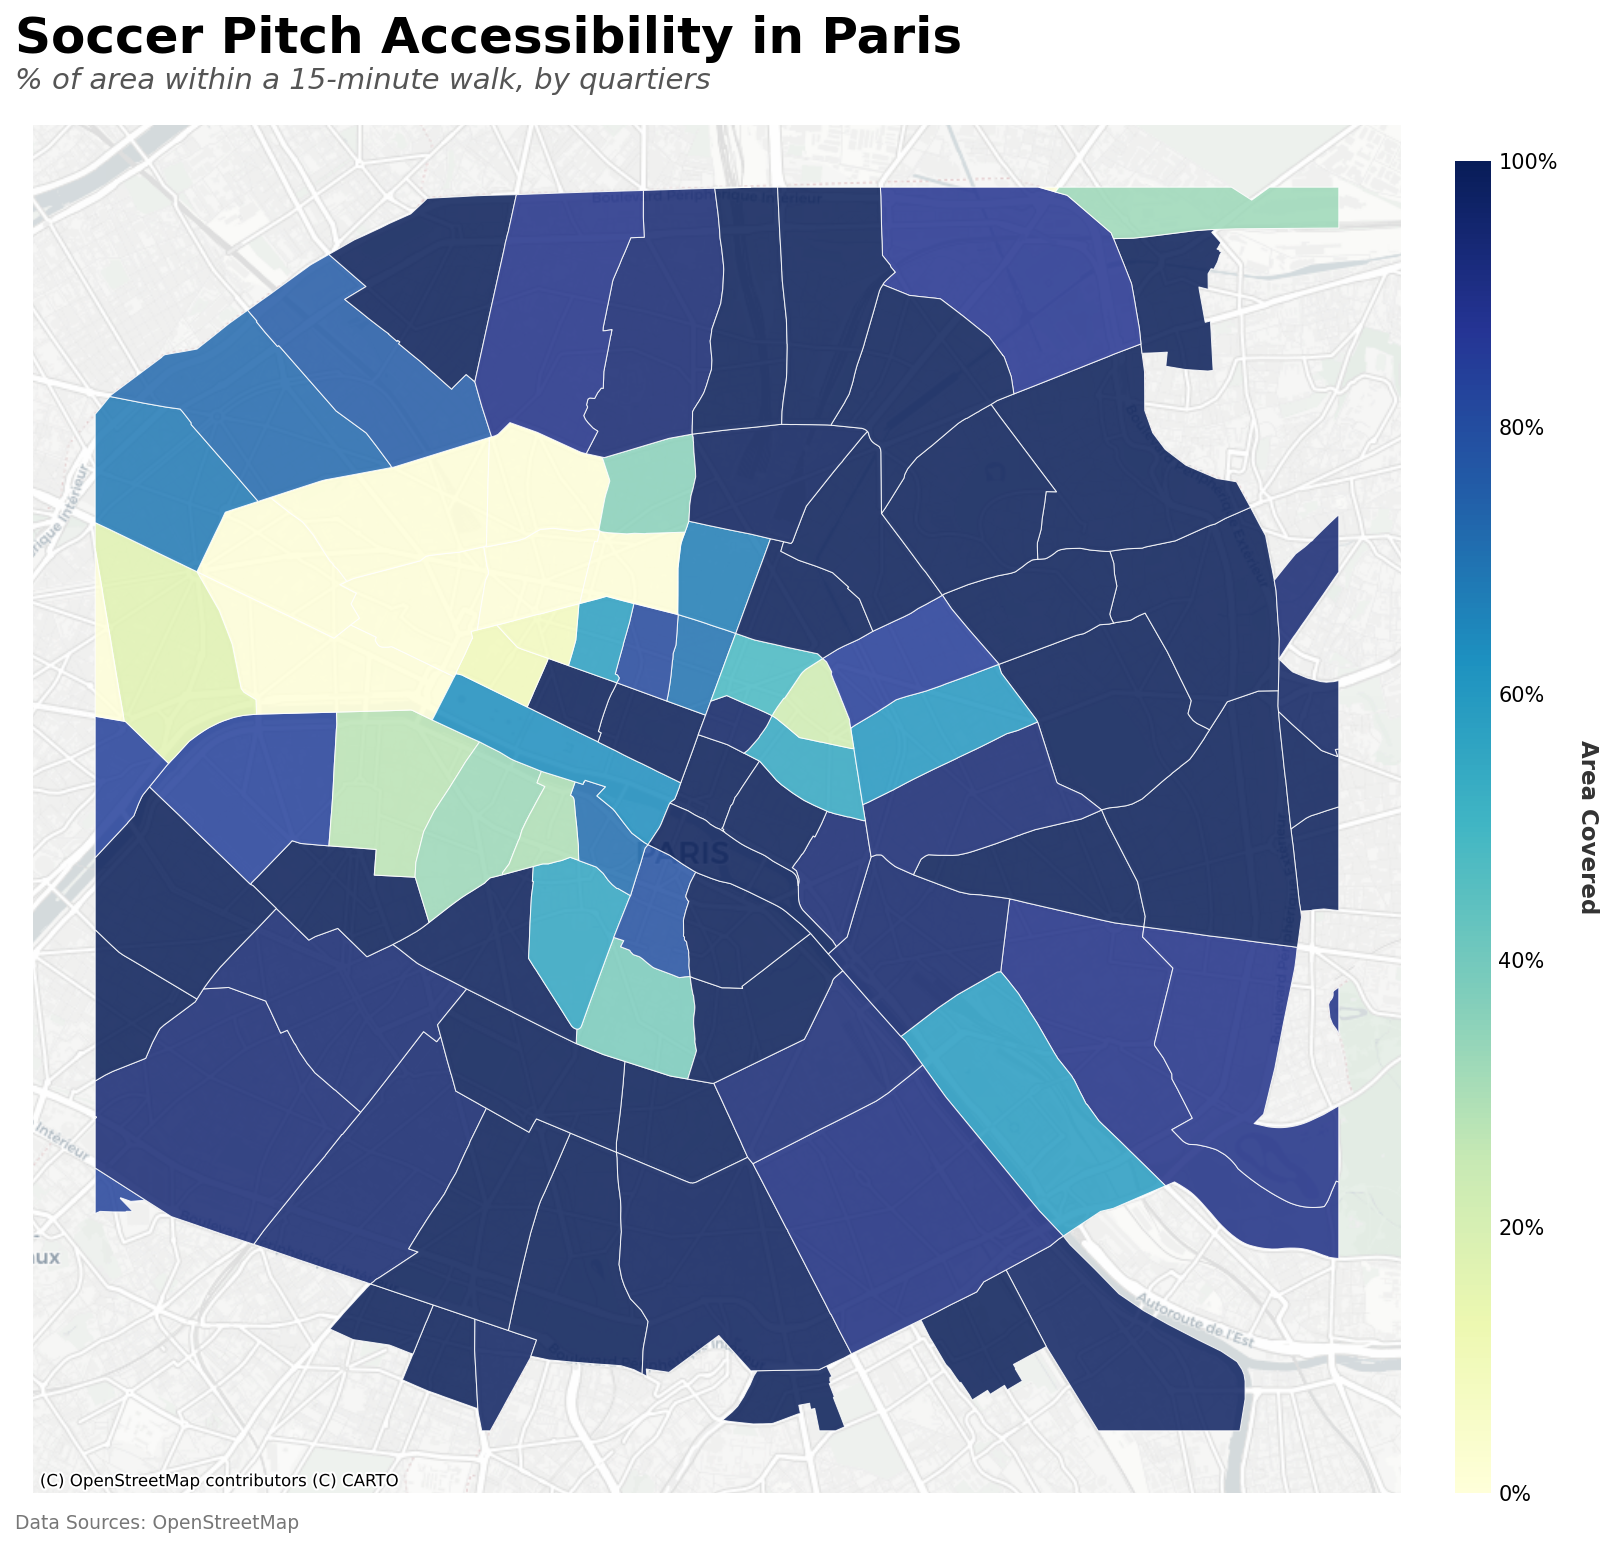

In [245]:
fig, ax = plt.subplots(figsize=(12, 12), dpi=150)
equity_results.to_crs(epsg=3857, inplace=True)


equity_results.plot(
    column='coverage_pct', 
    cmap='YlGnBu',
    edgecolor='white',
    linewidth=0.5,
    vmin=0,
    vmax=100,
    alpha=0.85,
    ax=ax
)

cx.add_basemap(ax=ax, source=cx.providers.CartoDB.Positron)

plt.figtext(0.05, 0.92, "Soccer Pitch Accessibility in Paris", fontsize=24, fontweight='bold', fontfamily='sans-serif')
plt.figtext(0.05, 0.90, "% of area within a 15-minute walk, by quartiers", fontsize=14, color='#555555', fontfamily='sans-serif', fontstyle='italic')

# Coordinates: [left, bottom, width, height]
cbar_ax = fig.add_axes([0.85, 0.12, 0.02, 0.74])
sm = plt.cm.ScalarMappable(cmap='YlGnBu', norm=plt.Normalize(vmin=0, vmax=100))
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')

cbar.set_label("Area Covered", fontsize=11, fontweight='bold', color='#333333', rotation=270, labelpad=20)
cbar.ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
cbar.outline.set_visible(False)  
cbar.ax.tick_params(size=0, labelsize=10, color='#333333')

plt.figtext(0.05, 0.1, "Data Sources: OpenStreetMap", fontsize=9, color='#777777')

ax.set_axis_off()
plt.subplots_adjust(left=0.06, right=0.82, top=0.9, bottom=0.1)

plt.show()